In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy.linalg import qr
from scipy.optimize import minimize
from collections import deque
from arch import arch_model
import warnings
import pydmd
from pydmd import DMD

warnings.filterwarnings("ignore")

# --------------------------------------------------
# Load Data
# --------------------------------------------------
GT = pd.read_csv('Temporature_history.csv', header=None).to_numpy()
CS_Data = pd.read_csv('Reconstructed_State.csv', header=None).to_numpy()
input_Data = pd.read_csv('Heat_input.csv', header=None).to_numpy()

nx, ny = int(np.sqrt(GT.shape[0])), int(np.sqrt(GT.shape[0]))
N = nx * ny

# ---------------------------------------------------
# 1. Basic sizes and measurement matrix H
# ---------------------------------------------------
p_sensor = 0.005 
m = int(p_sensor * N)  # 0.5% sensors
number_of_sensors = m

H = np.zeros((m, N))
indices = np.random.choice(N, m, replace=False)
for i, idx in enumerate(indices):
    H[i, idx] = 1


In [272]:
GT.shape, input_Data.shape

((10201, 1001), (4, 1000))

In [273]:
# ===================================================
# PART A: EM ALGORITHM TO ESTIMATE INITIAL Q (Q_EM)
# ===================================================

class KalmanDMDc:
    def __init__(self, dmd, GT, Input, U_r, Q, m=m, H=H):
        """
        dmd   : trained pydmd.DMDc object (on training data)
        GT    : full-order training data, shape (N, T_train)
        Input : training inputs, shape (nu, T_train-1)
        U_r   : POD/DMD basis, shape (N, r)
        Q     : process noise covariance in reduced space, shape (r, r)
        """
        self.dmd = dmd
        self.GT = GT
        self.Input = Input
        self.U_r = U_r
        self.rank = U_r.shape[1]

        # Use ONLY the training data passed in
        self.Data = GT
        self.reduced_data = U_r.T @ self.Data  # shape (r, T_train)

        self.B = U_r.T @ dmd.B                 # reduced B, shape (r, nu)
        self.F = dmd._Atilde.as_numpy_array    # reduced A, shape (r, r)

        self.N, self.timesteps = self.Data.shape
        self.m = m
        self.Q = Q
        self.H = H

        # Initial state and covariance in reduced coordinates
        self.x = self.reduced_data[:, 0]       # start from first training snapshot
        self.P = U_r.T @ (10 * np.eye(self.N)) @ U_r  # (r, r)
        self.R = 1e-3 * np.eye(self.m)         # measurement noise in sensor space

        # Output containers (in reduced space)
        self.X_pred = []      # predicted states x_{k|k-1}
        self.X_filtered = []  # filtered  states x_{k|k}
        self.P_pred = []      # predicted covariances P_{k|k-1}
        self.P_filtered = []  # filtered  covariances P_{k|k}

        self.rmse_vec = []
        self.mean_error = []
        self.rel_error = []

    def predict(self, u):
        # x_{k+1|k} = F x_{k|k} + B u_k
        self.x = self.F @ self.x + (self.B @ u).flatten()
        # P_{k+1|k} = F P_{k|k} F^T + Q
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x, self.P

    def update(self, z):
        # Measurement operator in reduced coordinates: HU * x_r
        HU = self.H @ self.U_r                     # (m, r)
        S = HU @ self.P @ HU.T + self.R            # innovation covariance
        K = self.P @ HU.T @ np.linalg.inv(S)       # Kalman gain

        y = z - HU @ self.x                        # innovation
        self.x = self.x + K @ y                    # x_{k|k}
        I = np.eye(self.P.shape[0])
        # Joseph form (numerically more stable)
        self.P = (I - K @ HU) @ self.P @ (I - K @ HU).T + K @ self.R @ K.T

        return self.x, self.P

    def run(self):
        """
        Run filter through *training* window only.
       indexindex k = 0,...,T_train-2, where:
          - u_k      = Input[:, k]
          - z_k      = measured from GT at index k
          - x_{k|k}  stored in X_filtered[:, k]
          - x_{k|k-1} stored in X_pred[:, k]
        """
        for k in range(self.timesteps - 1):
            print(f"Kalman step (training) k = {k}")

            # Input at time k (aligned with training window)
            u = self.Input[:, k]

            # "True" noisy observation (sensors) at time k
            z = self.H @ self.U_r @ self.reduced_data[:, k]

            # Prediction
            x_pred, P_pred = self.predict(u)
            self.X_pred.append(x_pred.real)
            self.P_pred.append(P_pred)

            # Update with measurement
            x_upd, P_upd = self.update(z)
            self.X_filtered.append(x_upd.real)
            self.P_filtered.append(P_upd)

            # Prepare for next step
            self.x = x_upd
            self.P = P_upd

            # Error diagnostics (optional)
            true_reduced = self.reduced_data[:, k + 1]
            full_pred = self.U_r @ x_upd.real
            full_true = self.Data[:, k + 1]

            rmse = np.sqrt(np.mean((full_pred - self.U_r @ true_reduced) ** 2))
            mean_err = np.mean(np.abs(x_upd.real - true_reduced))
            rel_err = np.sum(100 * np.abs(x_upd.real - true_reduced)) / np.sum(np.abs(full_true))

            self.rmse_vec.append(rmse)
            self.mean_error.append(mean_err)
            self.rel_error.append(rel_err)

            print(f"  RMSE               = {rmse:.4f}")
            print(f"  Mean Abs Error     = {mean_err:.4f}")
            print(f"  Total Rel Error(%) = {rel_err:.4f}")

        # Convert lists to arrays:
        X_pred_arr = np.array(self.X_pred).T
        X_filt_arr = np.array(self.X_filtered).T
        P_pred_arr = np.array(self.P_pred).transpose(1, 2, 0)
        P_filt_arr = np.array(self.P_filtered).transpose(1, 2, 0)

        return X_filt_arr, X_pred_arr, P_filt_arr, P_pred_arr


class KalmanSmoother:
    def __init__(self, F, X_pred, X_filt, P_pred, P_filt):
        """
        F       : reduced transition matrix (r, r)
        X_pred  : (r, T')   predicted states x_{k|k-1}
        X_filt  : (r, T')   filtered  states x_{k|k}
        P_pred  : (r, r, T')
        P_filt  : (r, r, T')
        """
        self.F = F
        self.X_pred = X_pred
        self.X_filt = X_filt
        self.P_pred = P_pred
        self.P_filt = P_filt

    def smooth(self):
        r, T = self.X_filt.shape

        X_smooth = np.zeros_like(self.X_filt)      # (r, T)
        P_smooth = np.zeros_like(self.P_filt)      # (r, r, T)
        P_cross = np.zeros_like(self.P_filt)       # (r, r, T)  stores P_{k,k+1|N}

        # Final time: smoother == filter
        X_smooth[:, -1] = self.X_filt[:, -1]
        P_smooth[:, :, -1] = self.P_filt[:, :, -1]

        # Backward RTS recursion
        for k in range(T - 2, -1, -1):
            P_f = self.P_filt[:, :, k]
            P_p_next = self.P_pred[:, :, k + 1]
            A = self.F

            # Smoother gain
            G = P_f @ A.T @ np.linalg.inv(P_p_next)

            # State
            X_smooth[:, k] = self.X_filt[:, k] + G @ (X_smooth[:, k + 1] - self.X_pred[:, k + 1])

            # Covariance
            P_smooth[:, :, k] = P_f + G @ (P_smooth[:, :, k + 1] - P_p_next) @ G.T

            # Cross-covariance P_{k, k+1 | N}
            P_cross[:, :, k] = G @ P_smooth[:, :, k + 1]

        return X_smooth, P_smooth, P_cross


# ---------------------------------------------------
# EM Training Settings
# ---------------------------------------------------
kalman_start = 300          # training window length
number_of_training_samples = kalman_start

GT_train = CS_Data[:, :number_of_training_samples]           # training data for DMDc/EM
Input_train = input_Data[:, :number_of_training_samples - 1]

# Train initial DMDc
dmd = pydmd.DMDc(svd_rank=10)
dmd.fit(GT_train, Input_train)

rank = dmd._Atilde.shape[0]
print(f"DMD rank (reduced state dimension): {rank}")

U_r = dmd.basis  # (N, r)
F = dmd._Atilde.as_numpy_array

# Initial Q in reduced space
Q0 = U_r.T @ np.eye(N) @ U_r      # = I_r, but written explicitly
Q_new = Q0.copy()
Q_old = Q0.copy()

max_iter = 100
tolerance = 1e-2
norm_vec = []

for iteration in range(max_iter):
    print(f"\n==============================")
    print(f"   EM Iteration: {iteration + 1}")
    print(f"==============================")

    # E-step: run Kalman filter and RTS smoother *on training data*
    kf_em = KalmanDMDc(dmd, GT_train, Input_train, U_r, Q_new, m=m, H=H)
    X_filtered, X_pred, P_filtered, P_pred = kf_em.run()

    ks = KalmanSmoother(F, X_pred, X_filtered, P_pred, P_filtered)
    X_smooth, P_smooth, P_cross = ks.smooth()

    Q_old = Q_new.copy()

    # M-step: update Q using smoothed covariances
    Q_Sum = np.zeros((rank, rank))
    Ar = F
    T_f = X_filtered.shape[1]  # T' = T_train - 1

    for k in range(T_f - 1):
        term = (
            P_smooth[:, :, k + 1]
            - Ar @ P_cross[:, :, k].T
            - P_cross[:, :, k] @ Ar.T
            + Ar @ P_smooth[:, :, k] @ Ar.T
        )
        Q_Sum += term

    Q_new = Q_Sum / T_f

    diff_norm = np.linalg.norm(Q_new - Q_old)
    norm_vec.append(diff_norm)
    print(f"   ||Q_new - Q_old|| = {diff_norm:.6e}")

    if diff_norm < tolerance:
        print(f"\n✅ EM convergence reached after {iteration + 1} iterations "
              f"with norm = {diff_norm:.4e}.")
        break

# This is the EM-optimal process covariance in reduced space
Q_EM = 0.5 * (Q_new + Q_new.T)  # symmetrize just in case
print("\nFinal estimated Q_EM (reduced space):")
print(Q_EM)


DMD rank (reduced state dimension): 10

   EM Iteration: 1


KeyboardInterrupt: 

In [ ]:
norm_vec

[np.float64(2.299489289528828),
 np.float64(0.40846400573391695),
 np.float64(0.1760475666483313),
 np.float64(0.09640241194903748),
 np.float64(0.05983285063677218),
 np.float64(0.040220607434747056),
 np.float64(0.0286044708698936),
 np.float64(0.021223528013106716),
 np.float64(0.016278877172004953),
 np.float64(0.012825988555196049),
 np.float64(0.010332567419953236),
 np.float64(0.008481359040999883)]

In [ ]:
# ===================================================
# PART B: DCC-GARCH-BASED ONLINE Q UPDATES
#        (EM Q_EM USED AS INITIAL / PRIOR)
# ===================================================

class KalmanFilter:
    def __init__(self, F, B, H, Q, R, x0, P0, U_r):
        self.F = F  # State transition model
        self.B = B
        self.H = H
        self.Q = Q
        self.R = R
        self.x = x0
        self.P = P0
        self.U_r = U_r

    def predict(self, u):
        # Predict the state and state covariance
        self.x = np.dot(self.F, self.x) + np.dot(self.B, u).flatten()
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q
        return self.x

    def update(self, z):
        # Compute the Kalman gain
        HU = self.H @ self.U_r
        S = np.dot(np.dot(HU, self.P), HU.T) + self.R
        K = np.dot(np.dot(self.P, HU.T), np.linalg.inv(S))

        # Update the state estimate and covariance matrix
        y = z - np.dot(HU, self.x)
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.P.shape[0])
        self.P = np.dot(I - np.dot(K, HU), self.P) + np.dot(np.dot(K, self.R), K.T)
        return self.x, self.P


# Function to estimate current Q from epsilon series using DCC-GARCH(1,1)
def estimate_Q_from_epsilons(eps_series, prev_Q=None):
    # eps_series: (T, rank)
    T, N = eps_series.shape
    if T < 20 or N == 0:
        if prev_Q is not None:
            return prev_Q
        return 1e-3 * np.eye(N)

    # Step 1: Univariate GARCH(1,1) for each series
    cond_vol = np.zeros((T, N))
    eta = np.zeros((T, N))
    for i in range(N):
        try:
            model = arch_model(eps_series[:, i], vol='Garch', p=1, q=1)
            fit = model.fit(disp='off', show_warning=False)
            cond_vol[:, i] = fit.conditional_volatility
            eta[:, i] = eps_series[:, i] / cond_vol[:, i]
        except Exception:
            # Fallback if fit fails
            cond_vol[:, i] = np.std(eps_series[:, i]) * np.ones(T)
            eta[:, i] = eps_series[:, i] / cond_vol[:, i]

    # Step 2: Unconditional cov of eta
    bar_Q = np.cov(eta, rowvar=False)
    if np.linalg.det(bar_Q) <= 0:
        bar_Q += 1e-6 * np.eye(N)

    # Step 3: DCC neg log-likelihood
    def dcc_neg_log_likelihood(params, eta, bar_Q):
        a, b = params
        if a <= 0 or b <= 0 or (a + b) >= 1:
            return np.inf
        ll = 0.0
        Q_t_prev = bar_Q.copy()

        # For t=0
        diag_sqrt = np.sqrt(np.diag(Q_t_prev))
        if np.any(diag_sqrt == 0):
            return np.inf
        R_t = Q_t_prev / np.outer(diag_sqrt, diag_sqrt)
        try:
            det_R = np.linalg.det(R_t)
            if det_R <= 0:
                return np.inf
            log_det_R = np.log(det_R)
            inv_R = np.linalg.inv(R_t)
            quad = eta[0] @ inv_R @ eta[0]
            ll += log_det_R + quad
        except Exception:
            return np.inf

        # For t=1 to T-1
        for t in range(1, T):
            outer = np.outer(eta[t - 1], eta[t - 1])
            Q_t = (1 - a - b) * bar_Q + a * outer + b * Q_t_prev

            diag_sqrt = np.sqrt(np.diag(Q_t))
            if np.any(diag_sqrt == 0):
                return np.inf
            R_t = Q_t / np.outer(diag_sqrt, diag_sqrt)
            try:
                det_R = np.linalg.det(R_t)
                if det_R <= 0:
                    return np.inf
                log_det_R = np.log(det_R)
                inv_R = np.linalg.inv(R_t)
                quad = eta[t] @ inv_R @ eta[t]
                ll += log_det_R + quad
            except Exception:
                return np.inf
            Q_t_prev = Q_t

        return ll

    # Optimize
    initial_params = [0.02, 0.95]
    bounds = [(1e-6, 0.5), (1e-6, 0.99)]
    res = minimize(dcc_neg_log_likelihood, initial_params, args=(eta, bar_Q),
                   method='L-BFGS-B', bounds=bounds)

    if not res.success:
        # Fallback: prefer previous Q if available
        if prev_Q is not None:
            return prev_Q
        return np.cov(eps_series, rowvar=False)

    a, b = res.x

    # Step 4: Recompute Q_t series with fitted params
    Q_t_series = np.zeros((T, N, N))
    Q_t = bar_Q
    Q_t_series[0] = Q_t
    for t in range(1, T):
        outer = np.outer(eta[t - 1], eta[t - 1])
        Q_t = (1 - a - b) * bar_Q + a * outer + b * Q_t
        Q_t_series[t] = Q_t

    # Step 5: Compute H_t = D_t R_t D_t for last t
    t = T - 1
    diag_sqrt_q = np.sqrt(np.diag(Q_t_series[t]))
    if np.any(diag_sqrt_q == 0):
        if prev_Q is not None:
            return prev_Q
        return np.cov(eps_series, rowvar=False)

    R_t = Q_t_series[t] / np.outer(diag_sqrt_q, diag_sqrt_q)
    D_t = np.diag(cond_vol[t])
    H_t = D_t @ R_t @ D_t

    # Ensure positive definite
    eigvals, _ = np.linalg.eig(H_t)
    if np.any(eigvals <= 0):
        if prev_Q is not None:
            return prev_Q
        H_t += 1e-6 * np.eye(N)

    return H_t


# ---------------------------------------------------
# Prepare data for ONLINE phase
# ---------------------------------------------------

# Online will assimilate GT beyond the training window
Data = GT[:, kalman_start + 1:]       # GT from step 301 onward
input_vec = input_Data[:, 100:-1]     # keep as in your working code
Input = np.array(input_vec)

N_full, timesteps = Data.shape
print("Online Data shape (N, timesteps):", N_full, timesteps)

B = U_r.T @ dmd.B
print("Input shape, B shape:", Input.shape, B.shape)

# Reuse same H as EM (m x N) already defined

Zm = H @ U_r @ (U_r.T @ Data)[:, 1]
print("Example sensor measurement shape:", Zm.shape)

R = 1 * np.eye(m)

# Initial state and covariance in reduced space
reduced_order_data = U_r.T @ Data
x0 = reduced_order_data[:, 0]
print(f'x0 shape: {x0.shape}')
P0 = np.eye(rank) * 1e-3  # Initial P0

# Initial epsilon buffer and Q using EM Q_EM as prior
initial_reduced = U_r.T @ CS_Data[:, :kalman_start]
initial_input = input_Data[:, :kalman_start - 1]
initial_eps = initial_reduced[:, 1:] - F @ initial_reduced[:, :-1] - B @ initial_input
initial_eps_array = initial_eps.T  # (kalman_start-1, rank)

epsilon_buffer = deque(maxlen=kalman_start)
for j in range(initial_eps.shape[1]):
    epsilon_buffer.append(initial_eps[:, j])

# Start with EM Q_EM, then refine with DCC-GARCH (optional)
Q = Q_EM.copy()
Q = 0.5 * (Q + Q.T)  # ensure symmetric
Q = estimate_Q_from_epsilons(initial_eps_array, prev_Q=Q)
print(f'Initial Q from EM + DCC-GARCH:\n{Q}')

# Online update parameters
update_freq = 100  # Update Q every 100 steps
min_window = 50

mean_error = []
rel_error = []
rmse_vec = []
updated_state_vec = np.zeros([N, kalman_start + timesteps + 1])
updated_state_vec[:, :kalman_start] = CS_Data[:, :kalman_start]
RMSE_VECTOR = []
# ---------------------------------------------------
# ONLINE FILTER + DCC-GARCH Q UPDATES
# ---------------------------------------------------
for i in range(timesteps - 1):
    print(f'\n===== Online step i = {i} =====')

    # Incremental DMDc / basis update every kalman_start steps
    prev_Ur = None
    # if i % kalman_start == 0 and i != 0:
    if i % 100 == 0 and i != 0:
        dmd_new = pydmd.DMDc(svd_rank=rank)
        dmd_new.fit(updated_state_vec[:, i:i + kalman_start],
                    Input[:, i:i + kalman_start - 1])
        prev_Ur = U_r.copy()
        U_r = dmd_new.basis
        print("Updated basis U_r shape:", U_r.shape)

        F = dmd_new._Atilde.as_numpy_array
        B = U_r.T @ dmd_new.B
        reduced_order_data = U_r.T @ Data

        # Project previous x0, P0 into new basis
        old_x0 = x0.copy()
        x0 = U_r.T @ prev_Ur @ old_x0

        old_P0 = P0.copy()
        M = U_r.T @ prev_Ur
        P0 = M @ old_P0 @ M.T

        # Transform epsilon buffer to new basis
        if len(epsilon_buffer) > 0:
            old_buffer = list(epsilon_buffer)
            new_buffer = [M @ eps for eps in old_buffer]
            epsilon_buffer.clear()
            for ne in new_buffer:
                epsilon_buffer.append(ne)

        # Transform old Q
        old_Q = Q.copy()
        Q = M @ old_Q @ M.T

        # Refit Q if enough data
        if len(epsilon_buffer) >= min_window:
            eps_array = np.array(list(epsilon_buffer))
            Q = estimate_Q_from_epsilons(eps_array, prev_Q=old_Q)
            print(f'Refitted Q after basis update at step {i}')

    # Create Kalman Filter instance with current Q
    kf = KalmanFilter(F, B, H, Q, R, x0, P0, U_r)

    # Predict step
    u = Input[:, i]
    kf.predict(u)
    pred_x = kf.x.copy()  # predicted reduced state

    # Measurement (synthetic: using true reduced state for evaluation)
    z = H @ U_r @ reduced_order_data[:, i]

    # Update step
    updated_state = kf.update(z)
    filtered_x = kf.x
    x0 = updated_state[0]
    P0 = updated_state[1]

    # Approximate process noise residual
    epsilon_t = filtered_x - pred_x
    epsilon_buffer.append(epsilon_t)

    # Update Q periodically with DCC-GARCH
    if (i + 1) % update_freq == 0 and len(epsilon_buffer) >= min_window:
        eps_array = np.array(list(epsilon_buffer))
        Q = estimate_Q_from_epsilons(eps_array, prev_Q=Q)
        print(f'Updated Q at step {i + 1}')

    # Error metrics
    rmse_vec.append(
        np.sqrt(np.mean((reduced_order_data[:, i + 1] - updated_state[0].real) ** 2))
    )
    mean_error.append(
        np.sqrt(np.mean((updated_state[0].real - reduced_order_data[:, i + 1]) ** 2))
    )
    rel_error.append(
        np.sum(100 * np.abs(updated_state[0].real - reduced_order_data[:, i + 1]))
        / np.sum(Data[:, i + 1])
    )

    print(f'RMSE (reduced):\t'
          f'{np.sqrt(np.mean((U_r @ updated_state[0].real - U_r @ reduced_order_data[:, i + 1]) ** 2))}')
    print(f'Mean Abs Error (full):\t'
          f'{np.mean(np.abs(U_r @ updated_state[0].real - GT[:, i + 1 + kalman_start]))}')
    print(f'Total Rel Error (full):\t'
          f'{np.sum(100 * np.abs(U_r @ updated_state[0].real - GT[:, i + 1 + kalman_start])) / np.sum(np.abs(GT[:, i + 1 + kalman_start]))}')

    updated_state_vec[:, kalman_start + i] = U_r @ updated_state[0]

    RMSE_VECTOR.append(np.sqrt(np.mean((U_r @ updated_state[0] - GT[:, kalman_start + i + 1]) ** 2)))

Online Data shape (N, timesteps): 10201 700
Input shape, B shape: (4, 899) (10, 4)
Example sensor measurement shape: (51,)
x0 shape: (10,)
Initial Q from EM + DCC-GARCH:
[[ 0.19698775 -0.1054209   0.07681149  0.08283323  0.02250134 -0.08743855
   0.03834836  0.00147806 -0.05549621 -0.03321496]
 [-0.1054209   0.18815085 -0.0936258  -0.04747814  0.00311189  0.07494874
  -0.05014371 -0.00872285  0.04591894  0.03064644]
 [ 0.07681149 -0.0936258   0.10805184  0.05671162 -0.00682349 -0.06333635
   0.04814004  0.0058447  -0.04320617 -0.02053506]
 [ 0.08283323 -0.04747814  0.05671162  0.08014357  0.01311815 -0.07531233
   0.04849615  0.00403352 -0.04456282 -0.03065999]
 [ 0.02250134  0.00311189 -0.00682349  0.01311815  0.0209002  -0.00337297
   0.00615149 -0.00106979 -0.01153085 -0.00915211]
 [-0.08743855  0.07494874 -0.06333635 -0.07531233 -0.00337297  0.1954956
  -0.06359073 -0.00812707  0.05133589  0.03541257]
 [ 0.03834836 -0.05014371  0.04814004  0.04849615  0.00615149 -0.06359073
   0.07

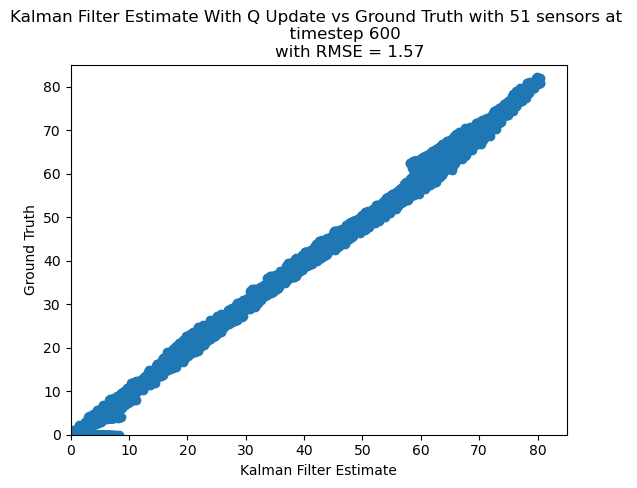

In [ ]:
index = 600
plt.Figure()
plt.scatter(updated_state_vec[:,index], GT[:,index])
plt.xlim(0,85)
plt.ylim(0,85)
plt.xlabel('Kalman Filter Estimate')
plt.ylabel('Ground Truth')
plt.title(f'Kalman Filter Estimate With Q Update vs Ground Truth with {number_of_sensors} sensors at \n\
          timestep {index}\n\
            with RMSE = {np.sqrt(np.mean((GT[:,index]-updated_state_vec[:,index])**2)):.2f}')
plt.show()

In [ ]:
np.mean(RMSE_VECTOR)

np.float64(1.669960665023736)

Prediction at time step 600


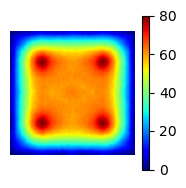

Ground Truth at time step 600


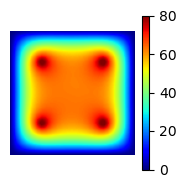

Error at time step 600


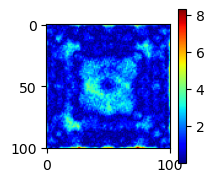

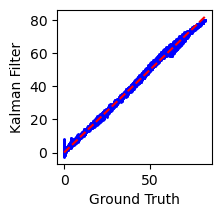

RMSE at 600th time step: 1.57


In [ ]:
index = 600
pred = updated_state_vec[:, index].reshape(nx, ny)
print(f'Prediction at time step {index}')
plt.figure(figsize= [2,2])
plt.axis('off')
plt.imshow(pred, cmap='jet', vmin = 0, vmax= 80)
plt.colorbar()
plt.show()
print(f'Ground Truth at time step {index}')
plt.figure(figsize= [2,2])
plt.axis('off')
plt.imshow(GT[:, index].reshape([101,101]), cmap='jet', vmin = 0, vmax= 80)
plt.colorbar()
plt.show()
print(f'Error at time step {index}')
plt.figure(figsize= [2,2])
plt.imshow(np.abs(pred- GT[:, index].reshape([101,101])), cmap='jet')
plt.colorbar()
plt.show()
plt.figure(figsize= [2,2])
plt.scatter(GT[:, index], updated_state_vec[:,index], color='blue', s=1)
plt.xlabel('Ground Truth', fontsize=10)
plt.ylabel('Kalman Filter', fontsize=10)
plt.plot([np.min(GT[:, index]), np.max(GT[:, index])],
         [np.min(GT[:, index]), np.max(GT[:, index])],
         color='red', linestyle='--')
plt.show()
print(f'RMSE at {index}th time step: {np.sqrt(np.mean((GT[:,index]-updated_state_vec[:,index])**2)):.2f}')

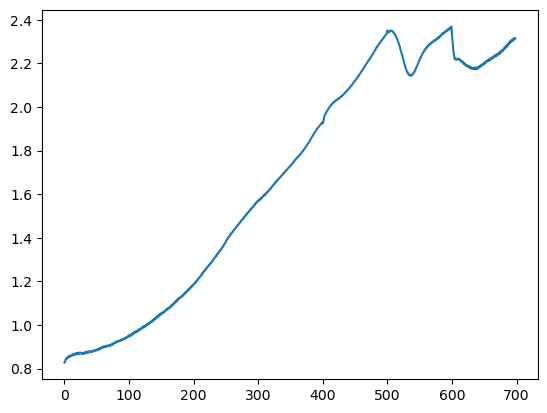

In [ ]:
# plt.plot(np.arange(301,1000), RMSE_VECTOR)
plt.plot(RMSE_VECTOR)

In [ ]:
RMSE_VECTOR[-1]

np.float64(2.3154635065054325)

In [ ]:
RMSE_VECTOR[:299]

[np.float64(0.8277713161949959),
 np.float64(0.8306259261359129),
 np.float64(0.8432356793852581),
 np.float64(0.8433526047056974),
 np.float64(0.8503424286199528),
 np.float64(0.847327022304721),
 np.float64(0.8553020570849104),
 np.float64(0.8519768798620684),
 np.float64(0.8582885542828016),
 np.float64(0.8552691487968138),
 np.float64(0.8610567792055001),
 np.float64(0.8578988048598687),
 np.float64(0.8634943403558408),
 np.float64(0.8601143685696101),
 np.float64(0.8671702026628005),
 np.float64(0.8632010868150188),
 np.float64(0.8679271479590317),
 np.float64(0.8633884159596458),
 np.float64(0.8704297170641377),
 np.float64(0.8652411340651782),
 np.float64(0.8706836019020676),
 np.float64(0.8658498697934982),
 np.float64(0.8721110008637392),
 np.float64(0.8675023374052612),
 np.float64(0.8738188261254081),
 np.float64(0.869228699600015),
 np.float64(0.8719752568763207),
 np.float64(0.8677401898469979),
 np.float64(0.8719735580328442),
 np.float64(0.8677645089845222),
 np.float64(

In [ ]:
rmse = RMSE_VECTOR

start = 301

print("\\addplot coordinates {")
for i, v in enumerate(rmse):
    print(f"({start + i},{v})")
print("};")

\addplot coordinates {
(301,0.8277713161949959)
(302,0.8306259261359129)
(303,0.8432356793852581)
(304,0.8433526047056974)
(305,0.8503424286199528)
(306,0.847327022304721)
(307,0.8553020570849104)
(308,0.8519768798620684)
(309,0.8582885542828016)
(310,0.8552691487968138)
(311,0.8610567792055001)
(312,0.8578988048598687)
(313,0.8634943403558408)
(314,0.8601143685696101)
(315,0.8671702026628005)
(316,0.8632010868150188)
(317,0.8679271479590317)
(318,0.8633884159596458)
(319,0.8704297170641377)
(320,0.8652411340651782)
(321,0.8706836019020676)
(322,0.8658498697934982)
(323,0.8721110008637392)
(324,0.8675023374052612)
(325,0.8738188261254081)
(326,0.869228699600015)
(327,0.8719752568763207)
(328,0.8677401898469979)
(329,0.8719735580328442)
(330,0.8677645089845222)
(331,0.8720925103101396)
(332,0.8678578851633783)
(333,0.8749645988357304)
(334,0.8703766827731645)
(335,0.8763934484827011)
(336,0.8715391119123149)
(337,0.8782271749447824)
(338,0.8731621426980095)
(339,0.8789315105486685)
(340

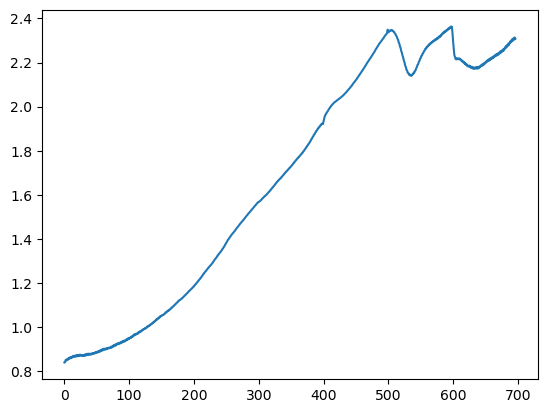

In [ ]:
plt.plot(np.sqrt(np.mean((updated_state_vec[:, 301:998] - GT[:, 301:998])**2, axis=0)))

In [ ]:
updated_state_vec

array([[19.67925121, 31.74202136, 20.04545691, ..., -4.53173867,
         0.        ,  0.        ],
       [ 1.39209072,  1.13632359,  0.97053588, ..., -1.70900037,
         0.        ,  0.        ],
       [66.59428016, 58.34268252, 45.40186715, ..., -4.22678076,
         0.        ,  0.        ],
       ...,
       [60.30530418, 54.39030518, 46.2298147 , ..., -5.11099455,
         0.        ,  0.        ],
       [ 1.79181146,  2.39610585,  2.64634788, ..., -1.77632237,
         0.        ,  0.        ],
       [24.42640942, 25.98506174, 15.79969318, ..., -3.67988185,
         0.        ,  0.        ]], shape=(10201, 1001))

SNR used: -2000 dB
Full-state signal power: 2471.821267
Full-state noise power : 247182126709011251880286522501120701904573598605758047255995982712978681547476462184673152301221243608963411237143886767524680358813127110744743979003728869017566669071457231358458677556892445080348000256.000000
Full-state noise std   : 497174141231230220346911150340533605866453333792348246906101578876714769613863136221434224160150650880.000000
Number of sensors = 51
DMD rank (reduced state dimension): 10

   EM Iteration: 1
Kalman step (training) k = 0
  RMSE               = 1.0426
  Mean Abs Error     = 31.3933
  Total Rel Error(%) = 0.0518
Kalman step (training) k = 1
  RMSE               = 4.4560
  Mean Abs Error     = 115.4375
  Total Rel Error(%) = 0.1907
Kalman step (training) k = 2
  RMSE               = 3.0118
  Mean Abs Error     = 82.4115
  Total Rel Error(%) = 0.1366
Kalman step (training) k = 3
  RMSE               = 2.0397
  Mean Abs Error     = 53.8197
  Total Rel Error(%) = 0.0895
Kalman st

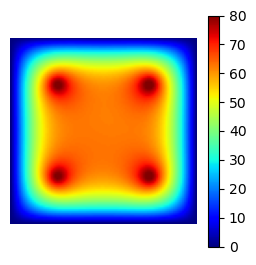

2. Noisy Ground Truth at time step 600


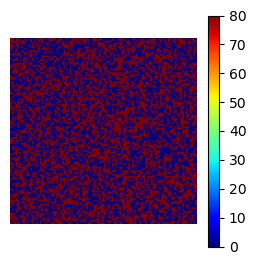

3. Prediction at time step 600


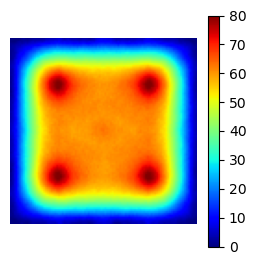

4. Error comparing Ground Truth without Noise and Prediction at time step 600


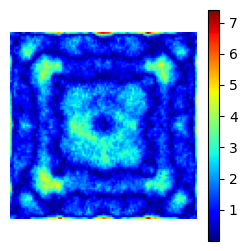

5. Scatter plot: Ground Truth without Noise vs Prediction at time step 600


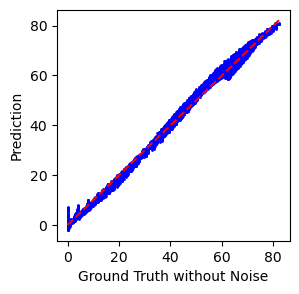

RMSE at 600th time step (vs clean GT): 1.67


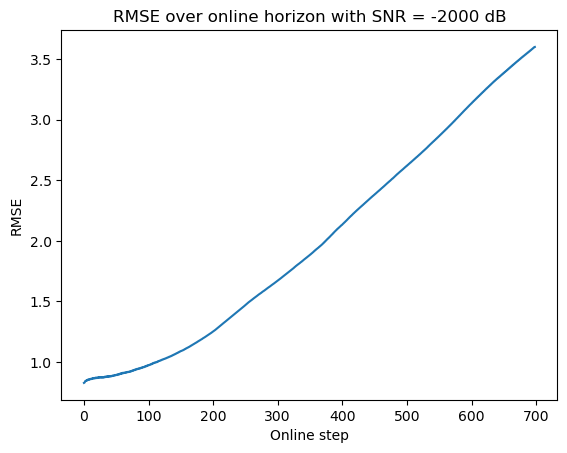

In [284]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy.linalg import qr
from scipy.optimize import minimize
from collections import deque
from arch import arch_model
import warnings
import pydmd
from pydmd import DMD

warnings.filterwarnings("ignore")

# ==================================================
# LOAD DATA
# ==================================================
GT = pd.read_csv('Temporature_history.csv', header=None).to_numpy()
CS_Data = pd.read_csv('Reconstructed_State.csv', header=None).to_numpy()
input_Data = pd.read_csv('Heat_input.csv', header=None).to_numpy()

# Keep clean GT for evaluation
GT_clean = GT.copy()

nx, ny = int(np.sqrt(GT.shape[0])), int(np.sqrt(GT.shape[0]))
N = nx * ny

# ==================================================
# ADD NOISE TO GROUND TRUTH: SNR = -5 dB
# ==================================================
def add_awgn_snr(signal, snr_db, seed=42):
    rng = np.random.default_rng(seed)
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10.0)
    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)
    noise = rng.normal(0.0, noise_std, size=signal.shape)
    noisy_signal = signal + noise
    return noisy_signal, noise, noise_power, noise_std

snr_db = -2000
GT_noisy, GT_noise, noise_power_full, noise_std_full = add_awgn_snr(GT_clean, snr_db, seed=42)

print(f"SNR used: {snr_db} dB")
print(f"Full-state signal power: {np.mean(GT_clean**2):.6f}")
print(f"Full-state noise power : {noise_power_full:.6f}")
print(f"Full-state noise std   : {noise_std_full:.6f}")

# ==================================================
# SENSOR SELECTION MATRIX H
# ==================================================
p_sensor = 0.005
m = int(p_sensor * N)
number_of_sensors = m

np.random.seed(42)
H = np.zeros((m, N))
indices = np.random.choice(N, m, replace=False)
for i, idx in enumerate(indices):
    H[i, idx] = 1

print(f"Number of sensors = {m}")

# ==================================================
# PART A: EM ALGORITHM TO ESTIMATE INITIAL Q
# ==================================================
class KalmanDMDc:
    def __init__(self, dmd, GT, Input, U_r, Q, m=m, H=H):
        self.dmd = dmd
        self.GT = GT
        self.Input = Input
        self.U_r = U_r
        self.rank = U_r.shape[1]

        self.Data = GT
        self.reduced_data = U_r.T @ self.Data

        self.B = U_r.T @ dmd.B
        self.F = dmd._Atilde.as_numpy_array

        self.N, self.timesteps = self.Data.shape
        self.m = m
        self.Q = Q
        self.H = H

        self.x = self.reduced_data[:, 0]
        self.P = U_r.T @ (10 * np.eye(self.N)) @ U_r
        self.R = 1e-3 * np.eye(self.m)

        self.X_pred = []
        self.X_filtered = []
        self.P_pred = []
        self.P_filtered = []

        self.rmse_vec = []
        self.mean_error = []
        self.rel_error = []

    def predict(self, u):
        self.x = self.F @ self.x + (self.B @ u).flatten()
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x, self.P

    def update(self, z):
        HU = self.H @ self.U_r
        S = HU @ self.P @ HU.T + self.R
        K = self.P @ HU.T @ np.linalg.inv(S)

        y = z - HU @ self.x
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ HU) @ self.P @ (I - K @ HU).T + K @ self.R @ K.T
        return self.x, self.P

    def run(self):
        for k in range(self.timesteps - 1):
            print(f"Kalman step (training) k = {k}")

            u = self.Input[:, k]

            # EM stage still uses training data directly
            z = self.H @ self.U_r @ self.reduced_data[:, k]

            x_pred, P_pred = self.predict(u)
            self.X_pred.append(x_pred.real)
            self.P_pred.append(P_pred)

            x_upd, P_upd = self.update(z)
            self.X_filtered.append(x_upd.real)
            self.P_filtered.append(P_upd)

            self.x = x_upd
            self.P = P_upd

            true_reduced = self.reduced_data[:, k + 1]
            full_pred = self.U_r @ x_upd.real
            full_true = self.Data[:, k + 1]

            rmse = np.sqrt(np.mean((full_pred - self.U_r @ true_reduced) ** 2))
            mean_err = np.mean(np.abs(x_upd.real - true_reduced))
            rel_err = np.sum(100 * np.abs(x_upd.real - true_reduced)) / np.sum(np.abs(full_true))

            self.rmse_vec.append(rmse)
            self.mean_error.append(mean_err)
            self.rel_error.append(rel_err)

            print(f"  RMSE               = {rmse:.4f}")
            print(f"  Mean Abs Error     = {mean_err:.4f}")
            print(f"  Total Rel Error(%) = {rel_err:.4f}")

        X_pred_arr = np.array(self.X_pred).T
        X_filt_arr = np.array(self.X_filtered).T
        P_pred_arr = np.array(self.P_pred).transpose(1, 2, 0)
        P_filt_arr = np.array(self.P_filtered).transpose(1, 2, 0)

        return X_filt_arr, X_pred_arr, P_filt_arr, P_pred_arr


class KalmanSmoother:
    def __init__(self, F, X_pred, X_filt, P_pred, P_filt):
        self.F = F
        self.X_pred = X_pred
        self.X_filt = X_filt
        self.P_pred = P_pred
        self.P_filt = P_filt

    def smooth(self):
        r, T = self.X_filt.shape

        X_smooth = np.zeros_like(self.X_filt)
        P_smooth = np.zeros_like(self.P_filt)
        P_cross = np.zeros_like(self.P_filt)

        X_smooth[:, -1] = self.X_filt[:, -1]
        P_smooth[:, :, -1] = self.P_filt[:, :, -1]

        for k in range(T - 2, -1, -1):
            P_f = self.P_filt[:, :, k]
            P_p_next = self.P_pred[:, :, k + 1]
            A = self.F

            G = P_f @ A.T @ np.linalg.inv(P_p_next)

            X_smooth[:, k] = self.X_filt[:, k] + G @ (X_smooth[:, k + 1] - self.X_pred[:, k + 1])
            P_smooth[:, :, k] = P_f + G @ (P_smooth[:, :, k + 1] - P_p_next) @ G.T
            P_cross[:, :, k] = G @ P_smooth[:, :, k + 1]

        return X_smooth, P_smooth, P_cross

# ==================================================
# EM TRAINING SETTINGS
# ==================================================
kalman_start = 300
number_of_training_samples = kalman_start

GT_train = CS_Data[:, :number_of_training_samples]
Input_train = input_Data[:, :number_of_training_samples - 1]

dmd = pydmd.DMDc(svd_rank=10)
dmd.fit(GT_train, Input_train)

rank = dmd._Atilde.shape[0]
print(f"DMD rank (reduced state dimension): {rank}")

U_r = dmd.basis
F = dmd._Atilde.as_numpy_array

Q0 = U_r.T @ np.eye(N) @ U_r
Q_new = Q0.copy()
Q_old = Q0.copy()

max_iter = 100
tolerance = 1e-2
norm_vec = []

for iteration in range(max_iter):
    print(f"\n==============================")
    print(f"   EM Iteration: {iteration + 1}")
    print(f"==============================")

    kf_em = KalmanDMDc(dmd, GT_train, Input_train, U_r, Q_new, m=m, H=H)
    X_filtered, X_pred, P_filtered, P_pred = kf_em.run()

    ks = KalmanSmoother(F, X_pred, X_filtered, P_pred, P_filtered)
    X_smooth, P_smooth, P_cross = ks.smooth()

    Q_old = Q_new.copy()

    Q_Sum = np.zeros((rank, rank))
    Ar = F
    T_f = X_filtered.shape[1]

    for k in range(T_f - 1):
        term = (
            P_smooth[:, :, k + 1]
            - Ar @ P_cross[:, :, k].T
            - P_cross[:, :, k] @ Ar.T
            + Ar @ P_smooth[:, :, k] @ Ar.T
        )
        Q_Sum += term

    Q_new = Q_Sum / T_f

    diff_norm = np.linalg.norm(Q_new - Q_old)
    norm_vec.append(diff_norm)
    print(f"   ||Q_new - Q_old|| = {diff_norm:.6e}")

    if diff_norm < tolerance:
        print(f"\nEM convergence reached after {iteration + 1} iterations with norm = {diff_norm:.4e}.")
        break

Q_EM = 0.5 * (Q_new + Q_new.T)
print("\nFinal estimated Q_EM (reduced space):")
print(Q_EM)

# ==================================================
# PART B: ONLINE KF WITH DCC-GARCH Q UPDATE
# ==================================================
class KalmanFilter:
    def __init__(self, F, B, H, Q, R, x0, P0, U_r):
        self.F = F
        self.B = B
        self.H = H
        self.Q = Q
        self.R = R
        self.x = x0
        self.P = P0
        self.U_r = U_r

    def predict(self, u):
        self.x = np.dot(self.F, self.x) + np.dot(self.B, u).flatten()
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q
        return self.x

    def update(self, z):
        HU = self.H @ self.U_r
        S = np.dot(np.dot(HU, self.P), HU.T) + self.R
        K = np.dot(np.dot(self.P, HU.T), np.linalg.inv(S))

        y = z - np.dot(HU, self.x)
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.P.shape[0])
        self.P = np.dot(I - np.dot(K, HU), self.P) + np.dot(np.dot(K, self.R), K.T)
        return self.x, self.P


def estimate_Q_from_epsilons(eps_series, prev_Q=None):
    T, Nq = eps_series.shape
    if T < 20 or Nq == 0:
        if prev_Q is not None:
            return prev_Q
        return 1e-3 * np.eye(Nq)

    cond_vol = np.zeros((T, Nq))
    eta = np.zeros((T, Nq))

    for i in range(Nq):
        try:
            model = arch_model(eps_series[:, i], vol='Garch', p=1, q=1)
            fit = model.fit(disp='off', show_warning=False)
            cond_vol[:, i] = fit.conditional_volatility
            eta[:, i] = eps_series[:, i] / cond_vol[:, i]
        except Exception:
            std_i = np.std(eps_series[:, i])
            if std_i < 1e-12:
                std_i = 1e-12
            cond_vol[:, i] = std_i * np.ones(T)
            eta[:, i] = eps_series[:, i] / cond_vol[:, i]

    bar_Q = np.cov(eta, rowvar=False)
    if np.ndim(bar_Q) == 0:
        bar_Q = np.array([[bar_Q]])

    if np.linalg.det(bar_Q) <= 0:
        bar_Q += 1e-6 * np.eye(Nq)

    def dcc_neg_log_likelihood(params, eta, bar_Q):
        a, b = params
        if a <= 0 or b <= 0 or (a + b) >= 1:
            return np.inf

        ll = 0.0
        Q_t_prev = bar_Q.copy()

        diag_sqrt = np.sqrt(np.diag(Q_t_prev))
        if np.any(diag_sqrt == 0):
            return np.inf

        R_t = Q_t_prev / np.outer(diag_sqrt, diag_sqrt)
        try:
            det_R = np.linalg.det(R_t)
            if det_R <= 0:
                return np.inf
            log_det_R = np.log(det_R)
            inv_R = np.linalg.inv(R_t)
            quad = eta[0] @ inv_R @ eta[0]
            ll += log_det_R + quad
        except Exception:
            return np.inf

        for t in range(1, T):
            outer = np.outer(eta[t - 1], eta[t - 1])
            Q_t = (1 - a - b) * bar_Q + a * outer + b * Q_t_prev

            diag_sqrt = np.sqrt(np.diag(Q_t))
            if np.any(diag_sqrt == 0):
                return np.inf

            R_t = Q_t / np.outer(diag_sqrt, diag_sqrt)
            try:
                det_R = np.linalg.det(R_t)
                if det_R <= 0:
                    return np.inf
                log_det_R = np.log(det_R)
                inv_R = np.linalg.inv(R_t)
                quad = eta[t] @ inv_R @ eta[t]
                ll += log_det_R + quad
            except Exception:
                return np.inf

            Q_t_prev = Q_t

        return ll

    initial_params = [0.02, 0.95]
    bounds = [(1e-6, 0.5), (1e-6, 0.99)]

    res = minimize(
        dcc_neg_log_likelihood,
        initial_params,
        args=(eta, bar_Q),
        method='L-BFGS-B',
        bounds=bounds
    )

    if not res.success:
        if prev_Q is not None:
            return prev_Q
        return np.cov(eps_series, rowvar=False)

    a, b = res.x

    Q_t_series = np.zeros((T, Nq, Nq))
    Q_t = bar_Q.copy()
    Q_t_series[0] = Q_t

    for t in range(1, T):
        outer = np.outer(eta[t - 1], eta[t - 1])
        Q_t = (1 - a - b) * bar_Q + a * outer + b * Q_t
        Q_t_series[t] = Q_t

    t = T - 1
    diag_sqrt_q = np.sqrt(np.diag(Q_t_series[t]))
    if np.any(diag_sqrt_q == 0):
        if prev_Q is not None:
            return prev_Q
        return np.cov(eps_series, rowvar=False)

    R_t = Q_t_series[t] / np.outer(diag_sqrt_q, diag_sqrt_q)
    D_t = np.diag(cond_vol[t])
    H_t = D_t @ R_t @ D_t

    eigvals = np.linalg.eigvals(H_t)
    if np.any(eigvals <= 0):
        if prev_Q is not None:
            return prev_Q
        H_t += 1e-6 * np.eye(Nq)

    return H_t

# ==================================================
# PREPARE ONLINE DATA
# ==================================================
Data_clean = GT_clean[:, kalman_start + 1:]
Data_noisy = GT_noisy[:, kalman_start + 1:]

input_vec = input_Data[:, 100:-1]
Input = np.array(input_vec)

N_full, timesteps = Data_clean.shape
print("Online clean data shape:", Data_clean.shape)
print("Online noisy data shape:", Data_noisy.shape)

B = U_r.T @ dmd.B
print("Input shape, B shape:", Input.shape, B.shape)

# Measurement noise covariance from actual injected noise in sensor space
measurement_noise = H @ (GT_noisy - GT_clean)[:, kalman_start + 1:]
measurement_var = np.var(measurement_noise, axis=1, ddof=1)
measurement_var = np.maximum(measurement_var, 1e-10)
R = np.diag(measurement_var)

print("R shape:", R.shape)
print("Average measurement variance:", np.mean(measurement_var))

reduced_order_data_clean = U_r.T @ Data_clean
x0 = reduced_order_data_clean[:, 0]
print(f"x0 shape: {x0.shape}")
P0 = np.eye(rank) * 1e-3

# Initial epsilon buffer from training side
initial_reduced = U_r.T @ CS_Data[:, :kalman_start]
initial_input = input_Data[:, :kalman_start - 1]
initial_eps = initial_reduced[:, 1:] - F @ initial_reduced[:, :-1] - B @ initial_input
initial_eps_array = initial_eps.T

epsilon_buffer = deque(maxlen=kalman_start)
for j in range(initial_eps.shape[1]):
    epsilon_buffer.append(initial_eps[:, j])

Q = Q_EM.copy()
Q = 0.5 * (Q + Q.T)
Q = estimate_Q_from_epsilons(initial_eps_array, prev_Q=Q)
print("Initial Q from EM + DCC-GARCH:")
print(Q)

update_freq = 100
min_window = 50

mean_error = []
rel_error = []
rmse_vec = []
updated_state_vec = np.zeros([N, kalman_start + timesteps + 1])
updated_state_vec[:, :kalman_start] = CS_Data[:, :kalman_start]
RMSE_VECTOR = []

# ==================================================
# ONLINE FILTER + DCC-GARCH Q UPDATES
# ==================================================
for i in range(timesteps - 1):
    print(f"\n===== Online step i = {i} =====")

    prev_Ur = None

    if i % 100 == 0 and i != 0:
        dmd_new = pydmd.DMDc(svd_rank=rank)
        dmd_new.fit(
            updated_state_vec[:, i:i + kalman_start],
            Input[:, i:i + kalman_start - 1]
        )

        prev_Ur = U_r.copy()
        U_r = dmd_new.basis
        print("Updated basis U_r shape:", U_r.shape)

        F = dmd_new._Atilde.as_numpy_array
        B = U_r.T @ dmd_new.B
        reduced_order_data_clean = U_r.T @ Data_clean

        old_x0 = x0.copy()
        x0 = U_r.T @ prev_Ur @ old_x0

        old_P0 = P0.copy()
        M = U_r.T @ prev_Ur
        P0 = M @ old_P0 @ M.T

        if len(epsilon_buffer) > 0:
            old_buffer = list(epsilon_buffer)
            new_buffer = [M @ eps for eps in old_buffer]
            epsilon_buffer.clear()
            for ne in new_buffer:
                epsilon_buffer.append(ne)

        old_Q = Q.copy()
        Q = M @ old_Q @ M.T

        if len(epsilon_buffer) >= min_window:
            eps_array = np.array(list(epsilon_buffer))
            Q = estimate_Q_from_epsilons(eps_array, prev_Q=old_Q)
            print(f"Refitted Q after basis update at step {i}")

    kf = KalmanFilter(F, B, H, Q, R, x0, P0, U_r)

    # Predict
    u = Input[:, i]
    kf.predict(u)
    pred_x = kf.x.copy()

    # IMPORTANT: use noisy measurements in physical space
    z = H @ Data_noisy[:, i]

    # Update
    updated_state = kf.update(z)
    filtered_x = kf.x
    x0 = updated_state[0]
    P0 = updated_state[1]

    epsilon_t = filtered_x - pred_x
    epsilon_buffer.append(epsilon_t)

    if (i + 1) % update_freq == 0 and len(epsilon_buffer) >= min_window:
        eps_array = np.array(list(epsilon_buffer))
        Q = estimate_Q_from_epsilons(eps_array, prev_Q=Q)
        print(f"Updated Q at step {i + 1}")

    full_pred = (U_r @ updated_state[0]).real
    full_true = Data_clean[:, i]

    rmse_full = np.sqrt(np.mean((full_pred - full_true) ** 2))
    mae_full = np.mean(np.abs(full_pred - full_true))
    tre_full = np.sum(100 * np.abs(full_pred - full_true)) / np.sum(np.abs(full_true))

    rmse_vec.append(rmse_full)
    mean_error.append(mae_full)
    rel_error.append(tre_full)

    print(f"RMSE (full, vs clean GT):\t{rmse_full}")
    print(f"Mean Abs Error (full):\t{mae_full}")
    print(f"Total Rel Error (full):\t{tre_full}")

    updated_state_vec[:, kalman_start + i] = full_pred
    RMSE_VECTOR.append(rmse_full)

print("\nFiltering finished.")
print(f"Average RMSE over online horizon: {np.mean(RMSE_VECTOR):.4f}")

# ==================================================
# PLOTS YOU ASKED FOR
# ==================================================
index = 600

gt_clean_img = GT_clean[:, index].reshape(nx, ny)
gt_noisy_img = GT_noisy[:, index].reshape(nx, ny)
pred_img = updated_state_vec[:, index].reshape(nx, ny)
err_img = np.abs(pred_img - gt_clean_img)

print(f'1. Ground Truth (without Noise) at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(gt_clean_img, cmap='jet', vmin=0, vmax=80)
plt.colorbar()
plt.show()

print(f'2. Noisy Ground Truth at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(gt_noisy_img, cmap='jet', vmin=0, vmax=80)
plt.colorbar()
plt.show()

print(f'3. Prediction at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(pred_img, cmap='jet', vmin=0, vmax=80)
plt.colorbar()
plt.show()

print(f'4. Error comparing Ground Truth without Noise and Prediction at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(err_img, cmap='jet')
plt.colorbar()
plt.show()

print(f'5. Scatter plot: Ground Truth without Noise vs Prediction at time step {index}')
plt.figure(figsize=[3, 3])
plt.scatter(GT_clean[:, index], updated_state_vec[:, index], color='blue', s=1)
plt.xlabel('Ground Truth without Noise', fontsize=10)
plt.ylabel('Prediction', fontsize=10)
plt.plot(
    [np.min(GT_clean[:, index]), np.max(GT_clean[:, index])],
    [np.min(GT_clean[:, index]), np.max(GT_clean[:, index])],
    color='red',
    linestyle='--'
)
plt.show()

print(f'RMSE at {index}th time step (vs clean GT): {np.sqrt(np.mean((GT_clean[:, index] - updated_state_vec[:, index])**2)):.2f}')

# ==================================================
# OPTIONAL RMSE PLOT
# ==================================================
plt.figure()
plt.plot(RMSE_VECTOR)
plt.xlabel('Online step')
plt.ylabel('RMSE')
plt.title(f'RMSE over online horizon with SNR = {snr_db} dB')
plt.show()

1. Ground Truth (without Noise) at time step 301


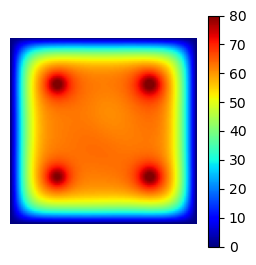

2. Noisy Ground Truth at time step 301


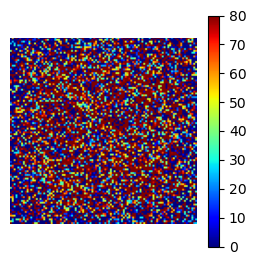

3. Prediction at time step 301


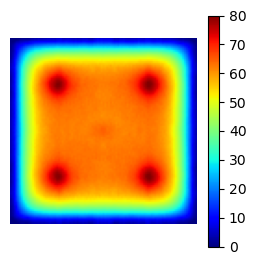

4. Error comparing Ground Truth without Noise and Prediction at time step 301


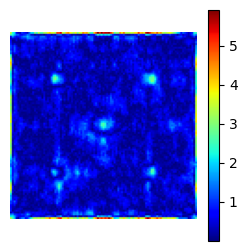

5. Scatter plot: Ground Truth without Noise vs Prediction at time step 301


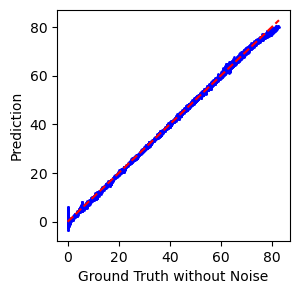

RMSE at 301th time step (vs clean GT): 0.84


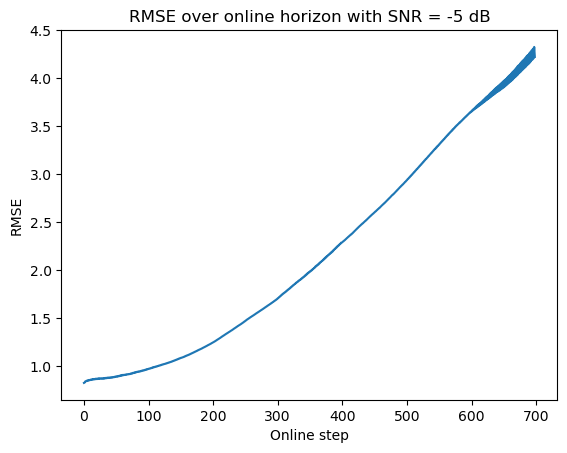

In [ ]:
# ==================================================
# PLOTS YOU ASKED FOR
# ==================================================
index = 301

gt_clean_img = GT_clean[:, index].reshape(nx, ny)
gt_noisy_img = GT_noisy[:, index].reshape(nx, ny)
pred_img = updated_state_vec[:, index].reshape(nx, ny)
err_img = np.abs(pred_img - gt_clean_img)

print(f'1. Ground Truth (without Noise) at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(gt_clean_img, cmap='jet', vmin=0, vmax=80)
plt.colorbar()
plt.show()

print(f'2. Noisy Ground Truth at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(gt_noisy_img, cmap='jet', vmin=0, vmax=80)
plt.colorbar()
plt.show()

print(f'3. Prediction at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(pred_img, cmap='jet', vmin=0, vmax=80)
plt.colorbar()
plt.show()

print(f'4. Error comparing Ground Truth without Noise and Prediction at time step {index}')
plt.figure(figsize=[3, 3])
plt.axis('off')
plt.imshow(err_img, cmap='jet')
plt.colorbar()
plt.show()

print(f'5. Scatter plot: Ground Truth without Noise vs Prediction at time step {index}')
plt.figure(figsize=[3, 3])
plt.scatter(GT_clean[:, index], updated_state_vec[:, index], color='blue', s=1)
plt.xlabel('Ground Truth without Noise', fontsize=10)
plt.ylabel('Prediction', fontsize=10)
plt.plot(
    [np.min(GT_clean[:, index]), np.max(GT_clean[:, index])],
    [np.min(GT_clean[:, index]), np.max(GT_clean[:, index])],
    color='red',
    linestyle='--'
)
plt.show()

print(f'RMSE at {index}th time step (vs clean GT): {np.sqrt(np.mean((GT_clean[:, index] - updated_state_vec[:, index])**2)):.2f}')

# ==================================================
# OPTIONAL RMSE PLOT
# ==================================================
plt.figure()
plt.plot(RMSE_VECTOR)
plt.xlabel('Online step')
plt.ylabel('RMSE')
plt.title(f'RMSE over online horizon with SNR = {snr_db} dB')
plt.show()